In [2]:
import os
import shutil
import random

# Define paths
dataset_path = r"E:\Major Project\archive (1)\Indian Medicinal Leaves Image Datasets\Medicinal Leaf dataset"
train_path = r"E:\Major Project\archive (1)\Indian Medicinal Leaves Image Datasets\train"
val_path = r"E:\Major Project\archive (1)\Indian Medicinal Leaves Image Datasets\val"
test_path = r"E:\Major Project\archive (1)\Indian Medicinal Leaves Image Datasets\test"

# Create train, val, test directories
for folder in [train_path, val_path, test_path]:
    os.makedirs(folder, exist_ok=True)

# Get all class names (subfolders)
classes = os.listdir(dataset_path)

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    # Check if it's a directory (avoid hidden files)
    if not os.path.isdir(cls_path):
        print(f"⚠️ Skipping {cls_path}, not a directory.")
        continue

    img_files = os.listdir(cls_path)
    random.shuffle(img_files)

    train_size = int(0.8 * len(img_files))  # 80%
    val_size = int(0.1 * len(img_files))    # 10%

    train_imgs = img_files[:train_size]
    val_imgs = img_files[train_size:train_size+val_size]
    test_imgs = img_files[train_size+val_size:]

    # Create class folders in train, val, and test if missing
    for split_path in [train_path, val_path, test_path]:
        class_dir = os.path.join(split_path, cls)
        os.makedirs(class_dir, exist_ok=True)

    # Move images
    def move_images(image_list, src_folder, dest_folder):
        for img in image_list:
            src = os.path.join(src_folder, img)
            dst = os.path.join(dest_folder, img)

            if os.path.exists(src):  # Ensure source file exists
                shutil.move(src, dst)
            else:
                print(f"⚠️ File missing: {src}")

    move_images(train_imgs, cls_path, os.path.join(train_path, cls))
    move_images(val_imgs, cls_path, os.path.join(val_path, cls))
    move_images(test_imgs, cls_path, os.path.join(test_path, cls))

print("✅ Dataset successfully split into Train, Val, and Test sets!")


✅ Dataset successfully split into Train, Val, and Test sets!


In [ ]:
import cv2
import numpy as np
import os

def remove_background(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_fg = np.where(mask == 255, 1, 0).astype('uint8')
    result = image * mask_fg[:, :, np.newaxis]
    white_bg = np.ones_like(image, dtype=np.uint8) * 255
    result = np.where(mask_fg[:, :, np.newaxis] == 1, result, white_bg)
    return result

def process_dataset(input_root, output_root):
    for split in ['train', 'val', 'test']:
        input_path = os.path.join(input_root, split)
        output_path = os.path.join(output_root, split)

        for class_name in os.listdir(input_path):
            class_input_path = os.path.join(input_path, class_name)
            class_output_path = os.path.join(output_path, class_name)
            os.makedirs(class_output_path, exist_ok=True)

            for img_name in os.listdir(class_input_path):
                img_path = os.path.join(class_input_path, img_name)
                image = cv2.imread(img_path)

                if image is not None:
                    processed = remove_background(image)
                    out_path = os.path.join(class_output_path, img_name.replace(".jpg", ".png"))

                    cv2.imwrite(out_path, processed, [cv2.IMWRITE_PNG_COMPRESSION, 9])

                  

                    print(f"✅ Saved: {out_path}")
                else:
                    print(f"❌ Failed to read: {img_path}")

# Dataset Paths
input_dataset_path = r"archive (1)/Indian Medicinal Leaves Image Datasets/dataset"
output_dataset_path = r"E:\Major Project\processed_data"

process_dataset(input_dataset_path, output_dataset_path)

Original exists: True
Processed exists: True


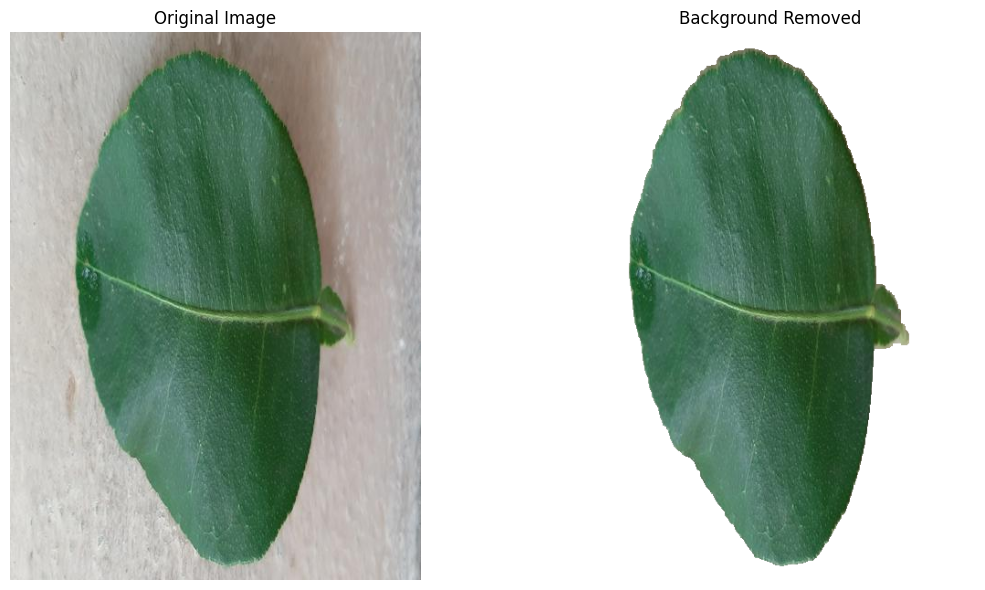

In [30]:
import cv2
import matplotlib.pyplot as plt
import os

# === Your image paths (update if needed) ===
original_img_path = r"E:\Major Project\archive (1)\Indian Medicinal Leaves Image Datasets\dataset\train\Lemon\18.jpg"
processed_img_path = r"E:\Major Project\Processed_data\train\Lemon\18.png"

# === Check if the files exist ===
print("Original exists:", os.path.exists(original_img_path))
print("Processed exists:", os.path.exists(processed_img_path))

# === Try reading the images ===
original = cv2.imread(original_img_path)
processed = cv2.imread(processed_img_path)

if original is None:
    print("❌ Failed to load original image. Check the path:", original_img_path)
elif processed is None:
    print("❌ Failed to load processed image. Check the path:", processed_img_path)
else:
    # Convert BGR to RGB for display
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    # Show side-by-side
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed_rgb)
    plt.title('Background Removed')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import os
import random
from tqdm import tqdm

# Paths
input_dir = r"E:\Major Project\prossessed_data_2\Medical leaf\Train"
output_dir = r"E:\Major Project\prossessed_data_2\Medical leaf\Train_augmented"

# Create output directory if not exist
os.makedirs(output_dir, exist_ok=True)

# Data Augmentation Configuration
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Number of augmented images per original image
aug_count = 2


augment_fraction = 0.2  # Only 20% of images will be augmented

for class_folder in tqdm(os.listdir(input_dir), desc="Processing Classes"):
    class_path = os.path.join(input_dir, class_folder)
    save_path = os.path.join(output_dir, class_folder)
    os.makedirs(save_path, exist_ok=True)

    all_images = os.listdir(class_path)
    to_augment = random.sample(all_images, int(len(all_images) * augment_fraction))

    for img_name in all_images:
        src_img_path = os.path.join(class_path, img_name)
        dst_img_path = os.path.join(save_path, img_name)
        
        # Copy original image to new folder
        try:
            img = load_img(src_img_path)
            img.save(dst_img_path, 'JPEG') 
        except Exception as e:
            print(f"❌ Error saving original {src_img_path}: {e}")
            continue

        # Only augment selected images
        if img_name in to_augment:
            try:
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                gen = datagen.flow(
                    x,
                    batch_size=1,
                    save_to_dir=save_path,
                    save_prefix='aug',
                    save_format='jpeg'
                )

                for i in range(aug_count):
                    next(gen)

            except Exception as e:
                print(f"❌ Error augmenting {src_img_path}: {e}")

print("✅ Selected data augmented and saved in JPEG format!")


Processing Classes: 100%|██████████████████████████████████████████████████████████████| 30/30 [02:59<00:00,  5.98s/it]

✅ Selected data augmented and saved in JPEG format!


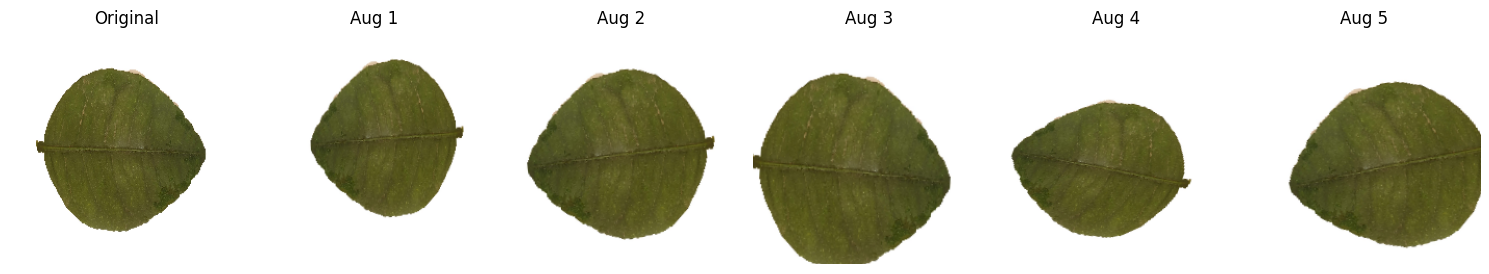

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Path to your original image
img_path = r"E:\Major Project\prossessed_data_2\Medical leaf\Train\Citrus Limon (Lemon)\CL-S-001.jpg"

# Load the image
img = load_img(img_path, target_size=(224, 224))  # Resize to model input size
x = img_to_array(img)
x = x.reshape((1,) + x.shape)  # Add batch dimension

# Data Augmentation configuration (same as training)
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate augmented images
augmented_images = []
gen = datagen.flow(x, batch_size=1)
for i in range(5):  # Show 5 augmented versions
    augmented_images.append(next(gen)[0].astype('uint8'))

# Plot original + augmented images
plt.figure(figsize=(15, 6))

# Original image
plt.subplot(1, 6, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

# Augmented images
for i, aug_img in enumerate(augmented_images):
    plt.subplot(1, 6, i + 2)
    plt.imshow(aug_img.astype('uint8'))
    plt.title(f"Aug {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = r"E:\Major Project\prossessed_data_2/Medical leaf/Train_augmented"
val_dir = r"E:\Major Project\prossessed_data_2/Medical leaf/val"

# ImageDataGenerator with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,                
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ImageDataGenerator for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  
    batch_size=32,
    class_mode='categorical'
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),  
    batch_size=32,
    class_mode='categorical'
)


Found 2009 images belonging to 30 classes.
Found 277 images belonging to 30 classes.


In [6]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG19 base model without the top (fully connected) layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers so they don’t get updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Combine base and top
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,454,878 (100.92 MB)

 Trainable params: 6,430,494 (24.53 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

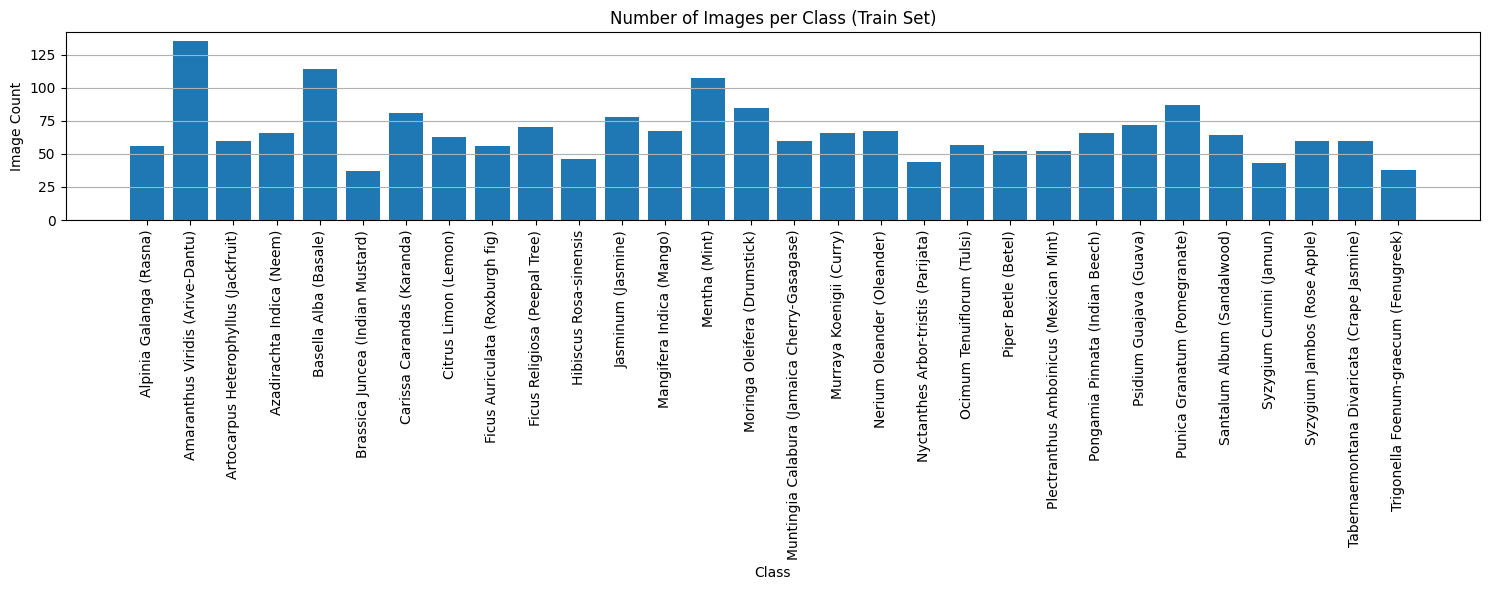

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Get class indices and reverse the dict to get class names by index
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Get the count of images per class from the generator
labels = train_generator.classes
class_counts = np.bincount(labels)

# Plot
plt.figure(figsize=(15, 6))
plt.bar(range(len(class_counts)), class_counts, tick_label=[index_to_class[i] for i in range(len(class_counts))])
plt.xticks(rotation=90)
plt.title("Number of Images per Class (Train Set)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model
checkpoint = ModelCheckpoint(
    'vgg19_leaf_best_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

# Stop training early if no improvement
earlystop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# Fit the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[checkpoint, earlystop]
)


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0973 - loss: 3.3856
Epoch 1: val_accuracy improved from -inf to 0.52347, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.0980 - loss: 3.3816 - val_accuracy: 0.5235 - val_loss: 2.2922
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2722 - loss: 2.6301
Epoch 2: val_accuracy improved from 0.52347 to 0.67509, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.2727 - loss: 2.6283 - val_accuracy: 0.6751 - val_loss: 1.6616
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4067 - loss: 2.1885
Epoch 3: val_accuracy improved from 0.67509 to 0.77617, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.4071 - loss: 2.1873 - val_accuracy: 0.7762 - val_loss: 1.2585
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4771 - loss: 1.8628
Epoch 4: val_accuracy improved from 0.77617 to 0.80866, saving model to vgg19_leaf_best_model.h5


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6395 - loss: 1.2546 - val_accuracy: 0.9495 - val_loss: 0.5023
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6523 - loss: 1.2071
Epoch 9: val_accuracy did not improve from 0.94946
63/63 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6524 - loss: 1.2069 - val_accuracy: 0.9314 - val_loss: 0.4502
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6522 - loss: 1.1286
Epoch 10: val_accuracy improved from 0.94946 to 0.95668, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6523 - loss: 1.1284 - val_accuracy: 0.9567 - val_loss: 0.3764
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7006 - loss: 1.0384
Epoch 11: val_accuracy improved from 0.95668 to 0.97112, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7007 - loss: 1.0384 - val_accuracy: 0.9711 - val_loss: 0.3486
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7042 - loss: 1.0236
Epoch 12: val_accuracy did not improve from 0.97112
63/63 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7041 - loss: 1.0236 - val_accuracy: 0.9639 - val_loss: 0.3378
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7317 - loss: 0.9671
Epoch 13: val_accuracy did not improve from 0.97112
63/63 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.7315 - loss: 0.9673 - val_accuracy: 0.9675 - val_loss: 0.3039
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7310 - loss: 0.9433
Epoch 14: val_accuracy improved from 0.97112 to 0.97834, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7312 - loss: 0.9428 - val_accuracy: 0.9783 - val_loss: 0.2740
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7438 - loss: 0.8762
Epoch 15: val_accuracy did not improve from 0.97834
63/63 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7439 - loss: 0.8759 - val_accuracy: 0.9783 - val_loss: 0.2331
Epoch 16/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7601 - loss: 0.8100
Epoch 16: val_accuracy did not improve from 0.97834
63/63 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.7601 - loss: 0.8101 - val_accuracy: 0.9747 - val_loss: 0.2336
Epoch 17/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7718 - loss: 0.8152
Epoch 17: val_accuracy improved from 0.97834 to 0.98556, saving model to vgg19_leaf_best_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 351s 6s/step - accuracy: 0.7716 - loss: 0.8154 - val_accuracy: 0.9856 - val_loss: 0.2244
Epoch 18/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7773 - loss: 0.7691
Epoch 18: val_accuracy did not improve from 0.98556
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7771 - loss: 0.7695 - val_accuracy: 0.9819 - val_loss: 0.2086
Epoch 19/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7863 - loss: 0.7446
Epoch 19: val_accuracy did not improve from 0.98556
63/63 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - accuracy: 0.7861 - loss: 0.7448 - val_accuracy: 0.9783 - val_loss: 0.2099
Epoch 20/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7926 - loss: 0.7479
Epoch 20: val_accuracy did not improve from 0.98556
63/63 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.7925 - loss: 0.7478 - val_accuracy: 0.9819 - val_loss: 0.1816
Restoring model weights from the end of the best epoch: 17.


In [11]:
print("Training class indices:", train_generator.class_indices)
print("Validation class indices:", val_generator.class_indices)
print("Number of training samples:", train_generator.samples)
print("Number of validation samples:", val_generator.samples)


Training class indices: {'Alpinia Galanga (Rasna)': 0, 'Amaranthus Viridis (Arive-Dantu)': 1, 'Artocarpus Heterophyllus (Jackfruit)': 2, 'Azadirachta Indica (Neem)': 3, 'Basella Alba (Basale)': 4, 'Brassica Juncea (Indian Mustard)': 5, 'Carissa Carandas (Karanda)': 6, 'Citrus Limon (Lemon)': 7, 'Ficus Auriculata (Roxburgh fig)': 8, 'Ficus Religiosa (Peepal Tree)': 9, 'Hibiscus Rosa-sinensis': 10, 'Jasminum (Jasmine)': 11, 'Mangifera Indica (Mango)': 12, 'Mentha (Mint)': 13, 'Moringa Oleifera (Drumstick)': 14, 'Muntingia Calabura (Jamaica Cherry-Gasagase)': 15, 'Murraya Koenigii (Curry)': 16, 'Nerium Oleander (Oleander)': 17, 'Nyctanthes Arbor-tristis (Parijata)': 18, 'Ocimum Tenuiflorum (Tulsi)': 19, 'Piper Betle (Betel)': 20, 'Plectranthus Amboinicus (Mexican Mint)': 21, 'Pongamia Pinnata (Indian Beech)': 22, 'Psidium Guajava (Guava)': 23, 'Punica Granatum (Pomegranate)': 24, 'Santalum Album (Sandalwood)': 25, 'Syzygium Cumini (Jamun)': 26, 'Syzygium Jambos (Rose Apple)': 27, 'Taberna

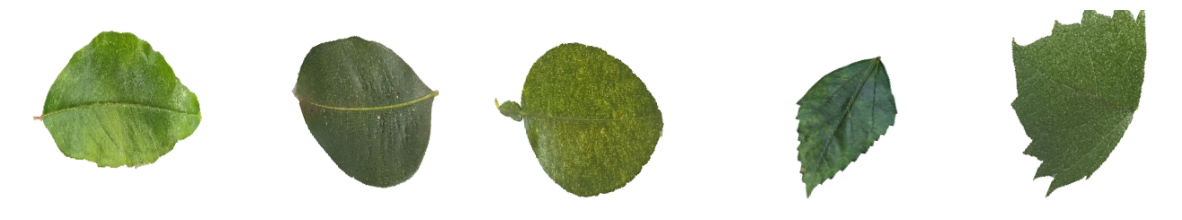

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(images[i])
    axes[i].axis("off")
plt.show()


In [14]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 39,315,868 (149.98 MB)

 Trainable params: 6,430,494 (24.53 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 12,860,990 (49.06 MB)

In [21]:
# Test generator
test_dir = r"E:\Major Project\prossessed_data_2\Medical leaf\Test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 380 images belonging to 30 classes.


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


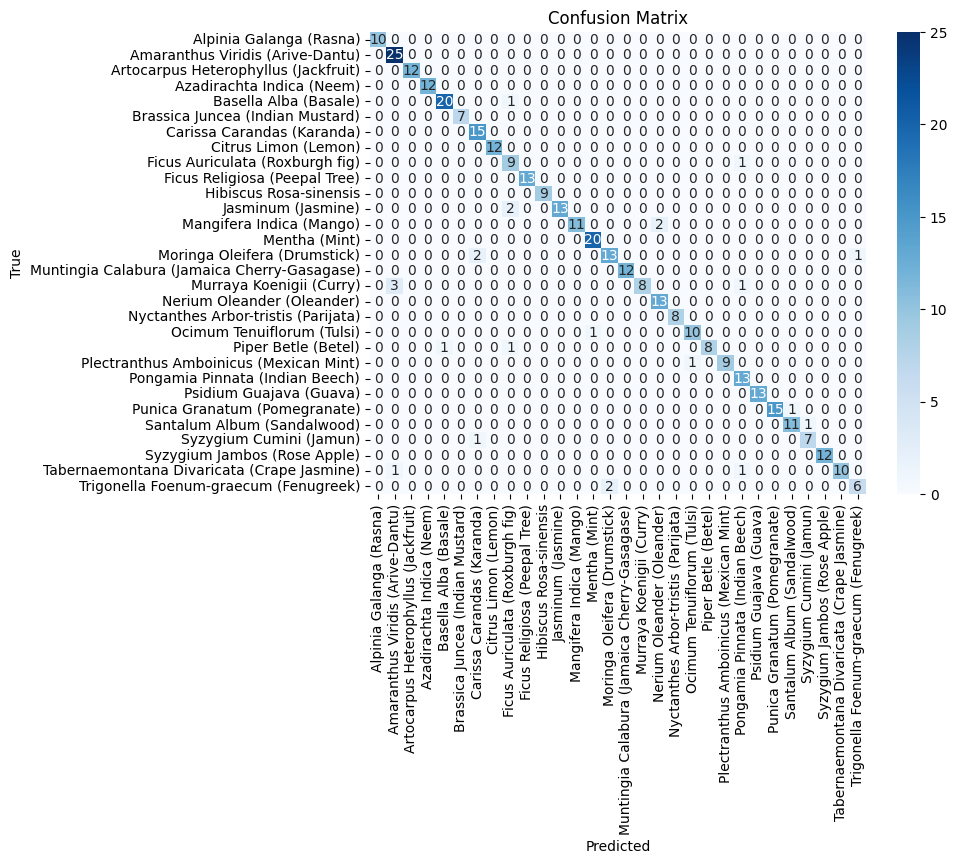

                                              precision    recall  f1-score   support

                     Alpinia Galanga (Rasna)       1.00      1.00      1.00        10
            Amaranthus Viridis (Arive-Dantu)       0.86      1.00      0.93        25
        Artocarpus Heterophyllus (Jackfruit)       1.00      1.00      1.00        12
                   Azadirachta Indica (Neem)       1.00      1.00      1.00        12
                       Basella Alba (Basale)       0.95      0.95      0.95        21
            Brassica Juncea (Indian Mustard)       1.00      1.00      1.00         7
                  Carissa Carandas (Karanda)       0.83      1.00      0.91        15
                        Citrus Limon (Lemon)       1.00      1.00      1.00        12
             Ficus Auriculata (Roxburgh fig)       0.69      0.90      0.78        10
               Ficus Religiosa (Peepal Tree)       1.00      1.00      1.00        13
                      Hibiscus Rosa-sinensis       1.

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(test_generator)
y_pred_labels = np.argmax(y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


print(classification_report(y_true, y_pred_labels, target_names=list(test_generator.class_indices.keys())))


In [25]:

model.save("vgg19_leaf_final_model.h5")
print("✅ Final model saved as vgg19_leaf_final_model.h5")


✅ Final model saved as vgg19_leaf_final_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
✅ Predicted class: Punica Granatum (Pomegranate)


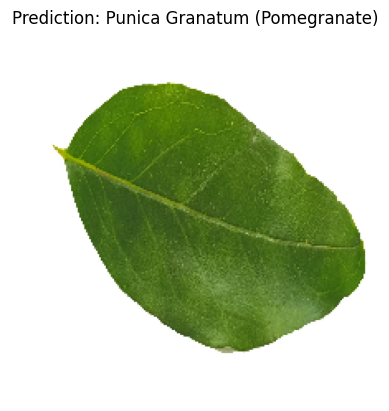

In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os


model = load_model("vgg19_leaf_final_model.h5") 

img_path = r"E:\Major Project\prossessed_data_2/Medical leaf/Test/Punica Granatum (Pomegranate)/PG-S-053.jpg"  # 🔁 Change this path to your image


img = load_img(img_path, target_size=(224, 224))  # Resize image to model input size
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  

# ==== Predict ====
pred = model.predict(img_array)
predicted_class_index = np.argmax(pred)


class_labels = list(train_generator.class_indices.keys())  
predicted_class = class_labels[predicted_class_index]

# ==== Show result ====
print(f"✅ Predicted class: {predicted_class}")


plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()


In [36]:

val_loss, val_accuracy = model.evaluate(val_generator)
print(f"✅ Validation Accuracy: {val_accuracy * 100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9842 - loss: 0.2131
✅ Validation Accuracy: 98.56%


In [37]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")


12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9624 - loss: 0.2588
✅ Test Accuracy: 93.68%
